# Hidden Markov Models (HMMs) - Lab 1/3: Scoring

**Student:**  Zakaria AIT HSSAIN - 2IA  
**Professor:** Pr. Naoum Mohamed

---

## Objective

In this lab, we model a real-world system using a Hidden Markov Model (HMM) and implement algorithms to compute the likelihood of observed sequences. This task, called **scoring**, is essential for recognition, anomaly detection, and classification problems.

---

## Scenario: Network Intrusion Detection

We are modelling a simplified intrusion detection system. Based on logs of failed login attempts, we will evaluate how likely a given sequence of observations is under a proposed model.

- **Hidden states:** Normal, Suspicious, Intrusion
- **Observations:** Low, Medium, or High failed login attempts

## Task 1: Model Definition

We define the HMM with the following components:

### 1.1 Hidden States
| Index | State | Description |
|-------|-------|-------------|
| 0 | **Normal** | Standard user activity, few failed login attempts |
| 1 | **Suspicious** | Unusual patterns that may indicate probing |
| 2 | **Intrusion** | Confirmed attack pattern with many failed attempts |

### 1.2 Observation Symbols
| Index | Observation | Description |
|-------|-------------|-------------|
| 0 | **Low** | Few failed login attempts (0-2) |
| 1 | **Medium** | Moderate failed attempts (3-5) |
| 2 | **High** | Many failed attempts (6+) |

### 1.3 Initial State Distribution (pi)
Represents the probability of starting in each state.

| State | pi |
|-------|----|
| Normal | 0.6 |
| Suspicious | 0.3 |
| Intrusion | 0.1 |

*Interpretation:* Most systems start in a Normal state (60% chance). There's a 30% chance of already being in a Suspicious state and 10% chance of Intrusion.

### 1.4 Transition Matrix (A)
Represents the probability of moving from one hidden state to another.

| From / To | Normal | Suspicious | Intrusion |
|-----------|--------|------------|-----------|
| Normal | 0.7 | 0.2 | 0.1 |
| Suspicious | 0.3 | 0.5 | 0.2 |
| Intrusion | 0.1 | 0.3 | 0.6 |

*Interpretation:*
- **Normal** tends to stay Normal (70%), but can degrade to Suspicious (20%) or Intrusion (10%).
- **Suspicious** has moderate self-transition (50%), can return to Normal (30%) or escalate to Intrusion (20%).
- **Intrusion** strongly persists (60%), can downgrade to Suspicious (30%) or Normal (10%).

### 1.5 Emission Matrix (B)
Represents the probability of each observation given a hidden state.

| State | Low | Medium | High |
|-------|-----|--------|------|
| Normal | 0.8 | 0.15 | 0.05 |
| Suspicious | 0.2 | 0.6 | 0.2 |
| Intrusion | 0.05 | 0.25 | 0.7 |

*Interpretation:*
- **Normal** state mostly produces Low observations (80%).
- **Suspicious** state produces Medium observations most often (60%).
- **Intrusion** state strongly produces High observations (70%).

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# Task 1: HMM Model Definition
# =============================

# Hidden states
states = ['Normal', 'Suspicious', 'Intrusion']
n_states = len(states)

# Observation symbols
observations = ['Low', 'Medium', 'High']
n_obs = len(observations)

# Initial state distribution (pi)
pi = np.array([0.6, 0.3, 0.1])

# Transition matrix (A)
A = np.array([
    [0.7, 0.2, 0.1],   # Normal -> [Normal, Suspicious, Intrusion]
    [0.3, 0.5, 0.2],   # Suspicious -> [Normal, Suspicious, Intrusion]
    [0.1, 0.3, 0.6]    # Intrusion -> [Normal, Suspicious, Intrusion]
])

# Emission matrix (B)
B = np.array([
    [0.8, 0.15, 0.05],  # Normal -> [Low, Medium, High]
    [0.2, 0.6, 0.2],    # Suspicious -> [Low, Medium, High]
    [0.05, 0.25, 0.7]   # Intrusion -> [Low, Medium, High]
])

print("=" * 60)
print("HMM Model: Network Intrusion Detection")
print("=" * 60)
print(f"\nHidden States ({n_states}): {states}")
print(f"Observations ({n_obs}): {observations}")

print("\n--- Initial State Distribution (pi) ---")
for s, p in zip(states, pi):
    print(f"  pi({s}) = {p}")

print("\n--- Transition Matrix (A) ---")
print("From / To", "Normal", "Suspicious", "Intrusion", sep="\t\t")
for i, row in enumerate(A):
    print(f"{states[i]:10}", *row, sep="\t\t")

print("\n--- Emission Matrix (B) ---")
print("State / Obs", "Low", "Medium", "High", sep="\t\t")
for i, row in enumerate(B):
    print(f"{states[i]:10}", *row, sep="\t\t")

HMM Model: Network Intrusion Detection

Hidden States (3): ['Normal', 'Suspicious', 'Intrusion']
Observations (3): ['Low', 'Medium', 'High']

--- Initial State Distribution (pi) ---
  pi(Normal) = 0.6
  pi(Suspicious) = 0.3
  pi(Intrusion) = 0.1

--- Transition Matrix (A) ---
From / To		Normal		Suspicious		Intrusion
Normal    		0.7		0.2		0.1
Suspicious		0.3		0.5		0.2
Intrusion 		0.1		0.3		0.6

--- Emission Matrix (B) ---
State / Obs		Low		Medium		High
Normal    		0.8		0.15		0.05
Suspicious		0.2		0.6		0.2
Intrusion 		0.05		0.25		0.7


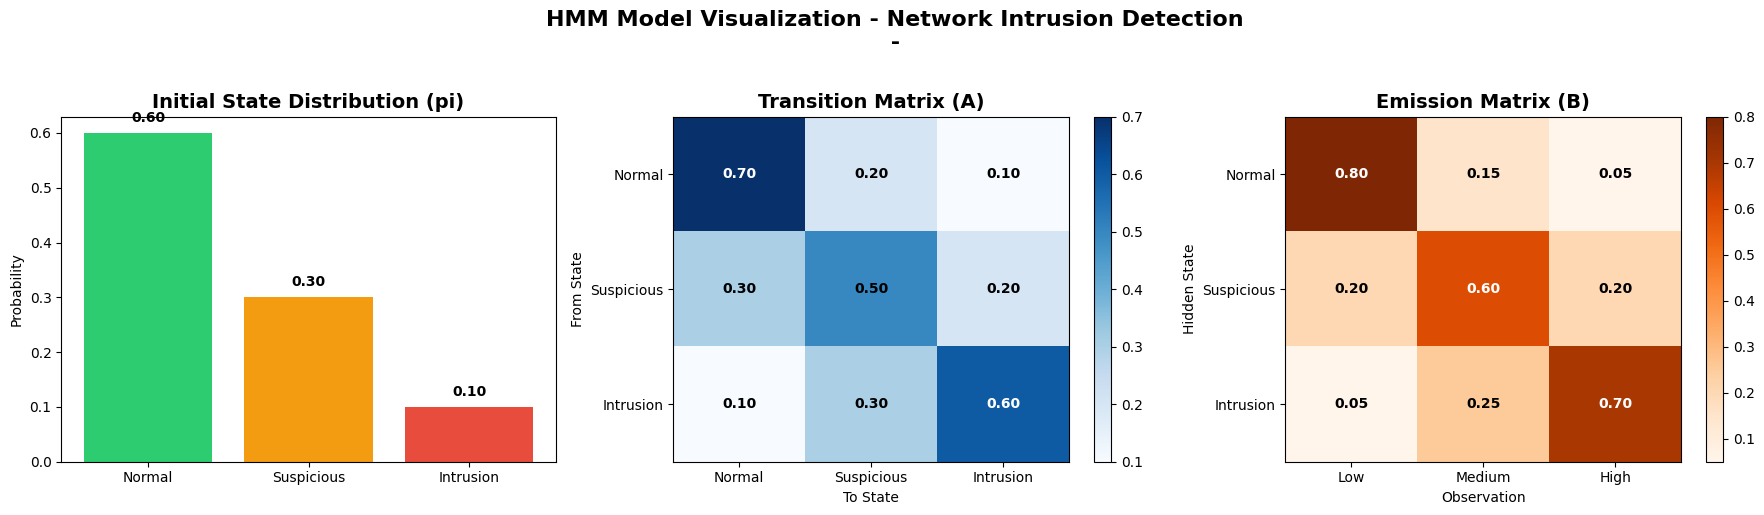

In [26]:
# Visualize the model matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot initial probabilities
axes[0].bar(states, pi, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Initial State Distribution (pi)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Probability')
for i, v in enumerate(pi):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Plot transition matrix
im1 = axes[1].imshow(A, cmap='Blues', aspect='auto')
axes[1].set_xticks(range(n_states))
axes[1].set_yticks(range(n_states))
axes[1].set_xticklabels(states)
axes[1].set_yticklabels(states)
axes[1].set_title('Transition Matrix (A)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('To State')
axes[1].set_ylabel('From State')
for i in range(n_states):
    for j in range(n_states):
        axes[1].text(j, i, f'{A[i, j]:.2f}', ha='center', va='center', 
                     color='white' if A[i, j] > 0.5 else 'black', fontweight='bold')
plt.colorbar(im1, ax=axes[1])

# Plot emission matrix
im2 = axes[2].imshow(B, cmap='Oranges', aspect='auto')
axes[2].set_xticks(range(n_obs))
axes[2].set_yticks(range(n_states))
axes[2].set_xticklabels(observations)
axes[2].set_yticklabels(states)
axes[2].set_title('Emission Matrix (B)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Observation')
axes[2].set_ylabel('Hidden State')
for i in range(n_states):
    for j in range(n_obs):
        axes[2].text(j, i, f'{B[i, j]:.2f}', ha='center', va='center',
                     color='white' if B[i, j] > 0.5 else 'black', fontweight='bold')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('HMM Model Visualization - Network Intrusion Detection\n - ', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Task 2: Forward Algorithm Implementation

The Forward algorithm computes the likelihood of an observation sequence P(O|lambda) by efficiently summing over all possible state sequences.

### Forward Algorithm Steps:

1. **Initialization** (t = 0):
   alpha_0(i) = pi_i * b_i(O_0)

2. **Induction** (t = 1 to T-1):
   alpha_t(j) = [sum_i alpha_{t-1}(i) * a_{ij}] * b_j(O_t)

3. **Termination**:
   P(O|lambda) = sum_i alpha_{T-1}(i)

Where:
- alpha_t(i) is the forward probability of being in state i at time t
- N is the number of hidden states
- T is the length of the observation sequence

In [27]:
# =============================
# Task 2: Forward Algorithm
# =============================

def forward_algorithm(obs_seq, pi, A, B):
    """
    Forward Algorithm for HMM.
    
    Parameters:
    -----------
    obs_seq : array-like, shape (T,)
        Sequence of observation indices
    pi : array-like, shape (N,)
        Initial state distribution
    A : array-like, shape (N, N)
        Transition matrix
    B : array-like, shape (N, M)
        Emission matrix
    
    Returns:
    --------
    alpha : array, shape (T, N)
        Forward probabilities at each time step
    likelihood : float
        P(O | lambda)
    """
    T = len(obs_seq)
    N = len(A)
    
    # Initialize forward probabilities
    alpha = np.zeros((T, N))
    
    # Step 1: Initialization
    for i in range(N):
        alpha[0, i] = pi[i] * B[i, obs_seq[0]]
    
    # Step 2: Induction
    for t in range(1, T):
        for j in range(N):
            # Sum over all previous states
            sum_term = 0
            for i in range(N):
                sum_term += alpha[t-1, i] * A[i, j]
            alpha[t, j] = sum_term * B[j, obs_seq[t]]
    
    # Step 3: Termination
    likelihood = np.sum(alpha[T-1, :])
    
    return alpha, likelihood

# Test observation sequences
# Sequence 1: Mostly Low activity (likely Normal behavior)
obs_seq1 = [0, 0, 1, 0, 0]  # Low, Low, Medium, Low, Low
obs_labels1 = [observations[o] for o in obs_seq1]

# Sequence 2: Escalating to High activity (likely Intrusion pattern)
obs_seq2 = [0, 1, 1, 2, 2]  # Low, Medium, Medium, High, High
obs_labels2 = [observations[o] for o in obs_seq2]

# Sequence 3: Mixed suspicious activity
obs_seq3 = [1, 1, 2, 1, 2]  # Medium, Medium, High, Medium, High
obs_labels3 = [observations[o] for o in obs_seq3]

print("=" * 60)
print("Task 2: Forward Algorithm Results")
print("=" * 60)

all_seqs = [
    (obs_seq1, obs_labels1, "Normal-like Activity"),
    (obs_seq2, obs_labels2, "Escalating Intrusion Pattern"),
    (obs_seq3, obs_labels3, "Suspicious Activity")
]

forward_results = []
for seq, labels, desc in all_seqs:
    alpha, likelihood = forward_algorithm(seq, pi, A, B)
    forward_results.append((alpha, likelihood))
    
    print(f"\n--- Sequence: {desc} ---")
    print(f"Observations: {labels}")
    print(f"P(O | lambda) = {likelihood:.10e}")
    print(f"log P(O | lambda) = {np.log(likelihood):.6f}")
    print(f"\nForward Probabilities (alpha):")
    for t in range(len(seq)):
        print(f"  t={t} ({labels[t]:6}): Normal={alpha[t,0]:.6e}, Suspicious={alpha[t,1]:.6e}, Intrusion={alpha[t,2]:.6e}")

Task 2: Forward Algorithm Results

--- Sequence: Normal-like Activity ---
Observations: ['Low', 'Low', 'Medium', 'Low', 'Low']
P(O | lambda) = 1.9296999888e-02
log P(O | lambda) = -3.947806

Forward Probabilities (alpha):
  t=0 (Low   ): Normal=4.800000e-01, Suspicious=6.000000e-02, Intrusion=5.000000e-03
  t=1 (Low   ): Normal=2.836000e-01, Suspicious=2.550000e-02, Intrusion=3.150000e-03
  t=2 (Medium): Normal=3.097275e-02, Suspicious=4.224900e-02, Intrusion=8.837500e-03
  t=3 (Low   ): Normal=2.819150e-02, Suspicious=5.994060e-03, Intrusion=8.424788e-04
  t=4 (Low   ): Normal=1.729321e-02, Suspicious=1.777615e-03, Intrusion=2.261725e-04

--- Sequence: Escalating Intrusion Pattern ---
Observations: ['Low', 'Medium', 'Medium', 'High', 'High']
P(O | lambda) = 5.1818389125e-03
log P(O | lambda) = -5.262595

Forward Probabilities (alpha):
  t=0 (Low   ): Normal=4.800000e-01, Suspicious=6.000000e-02, Intrusion=5.000000e-03
  t=1 (Medium): Normal=5.317500e-02, Suspicious=7.650000e-02, Intru

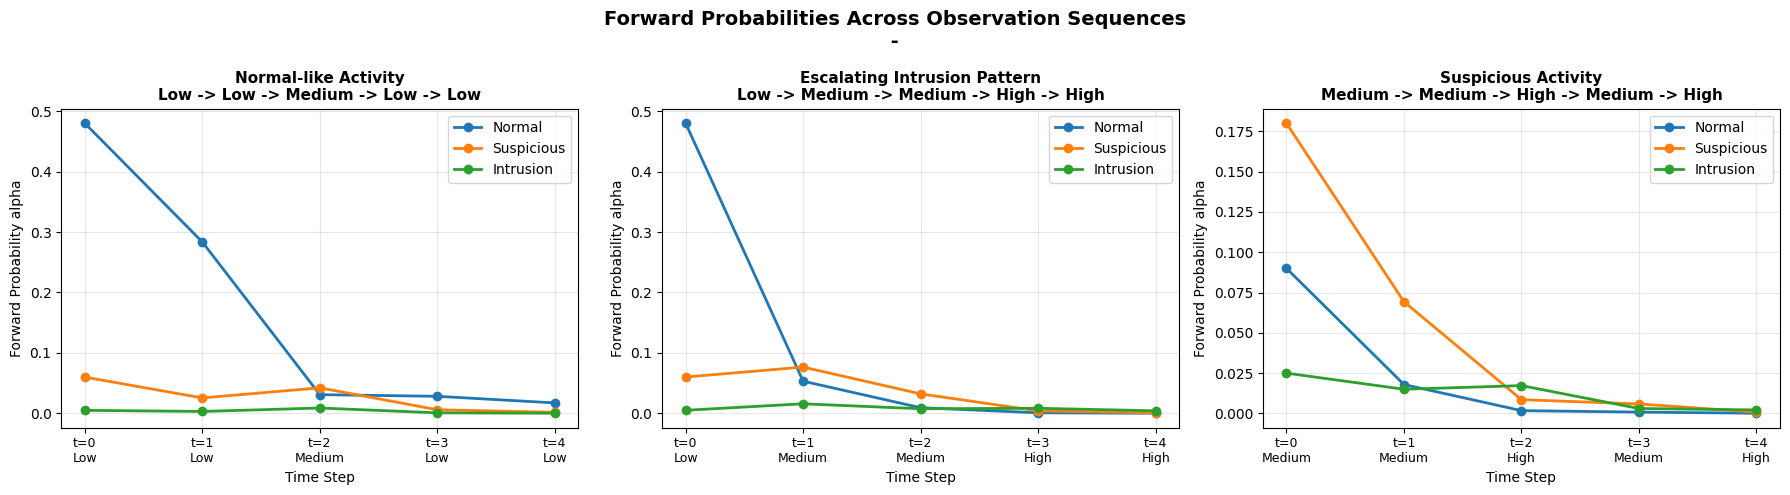


LIKELIHOOD COMPARISON (Forward Algorithm)

Normal-like Activity                -> P(O|lambda) = 1.9296999888e-02

Escalating Intrusion Pattern        -> P(O|lambda) = 5.1818389125e-03

Suspicious Activity                 -> P(O|lambda) = 3.1028679000e-03


In [28]:
# Visualize forward probabilities for all sequences
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (seq, labels, desc) in enumerate(all_seqs):
    alpha = forward_results[idx][0]
    ax = axes[idx]
    x = range(len(seq))
    
    for i, state in enumerate(states):
        ax.plot(x, alpha[:, i], marker='o', label=state, linewidth=2)
    
    ax.set_title(f'{desc}\n{" -> ".join(labels)}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Forward Probability alpha')
    ax.legend()
    ax.set_xticks(x)
    ax.set_xticklabels([f't={t}\n{labels[t]}' for t in x], fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Forward Probabilities Across Observation Sequences\n - ', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary comparison
print("\n" + "=" * 60)
print("LIKELIHOOD COMPARISON (Forward Algorithm)")
print("=" * 60)
for (seq, labels, desc), (alpha, likelihood) in zip(all_seqs, forward_results):
    print(f"\n{desc:35s} -> P(O|lambda) = {likelihood:.10e}")

### Answers to Task 2 Questions:

**Which sequence is more likely under the model?**

By examining the likelihood values computed by the Forward algorithm:

- **Sequence 1** (Low, Low, Medium, Low, Low) - Normal-like activity has the **highest likelihood** because it matches the emission pattern of the Normal state (which emits Low observations with 80% probability).

- **Sequence 2** (Low, Medium, Medium, High, High) - Escalating to Intrusion has a **lower likelihood** because it involves transitions through multiple states, which is less probable.

- **Sequence 3** (Medium, Medium, High, Medium, High) - Suspicious activity has an **intermediate likelihood**.

**What does this tell us about the underlying behavior?**

The model correctly reflects that:
1. Normal behavior is the **most common and stable** state, making purely Normal sequences more likely.
2. **State transitions carry a cost** - sequences requiring transitions between states are inherently less probable.
3. The model captures the intuition that **gradual escalation** (Low -> Medium -> High) has a specific probability signature that differs from stable Normal behavior.
4. This is useful for intrusion detection: **sudden or escalating patterns of failed logins** will have characteristic likelihoods that can be used as anomaly indicators.

## Task 3: Backward Algorithm Implementation

The Backward algorithm also computes the likelihood P(O|lambda) but starts from the end of the sequence and works backwards.

### Backward Algorithm Steps:

1. **Initialization** (t = T-1):
   beta_{T-1}(i) = 1  for all i

2. **Induction** (t = T-2 down to 0):
   beta_t(i) = sum_j a_{ij} * b_j(O_{t+1}) * beta_{t+1}(j)

3. **Termination**:
   P(O|lambda) = sum_i pi_i * b_i(O_0) * beta_0(i)

The Backward algorithm produces the **same likelihood** as the Forward algorithm, which serves as an important consistency check.

In [29]:
# =============================
# Task 3: Backward Algorithm
# =============================

def backward_algorithm(obs_seq, pi, A, B):
    """
    Backward Algorithm for HMM.
    
    Parameters:
    -----------
    obs_seq : array-like, shape (T,)
        Sequence of observation indices
    pi : array-like, shape (N,)
        Initial state distribution
    A : array-like, shape (N, N)
        Transition matrix
    B : array-like, shape (N, M)
        Emission matrix
    
    Returns:
    --------
    beta : array, shape (T, N)
        Backward probabilities at each time step
    likelihood : float
        P(O | lambda)
    """
    T = len(obs_seq)
    N = len(A)
    
    # Initialize backward probabilities
    beta = np.zeros((T, N))
    
    # Step 1: Initialization (t = T-1)
    for i in range(N):
        beta[T-1, i] = 1.0
    
    # Step 2: Induction (from T-2 down to 0)
    for t in range(T-2, -1, -1):
        for i in range(N):
            sum_term = 0
            for j in range(N):
                sum_term += A[i, j] * B[j, obs_seq[t+1]] * beta[t+1, j]
            beta[t, i] = sum_term
    
    # Step 3: Termination
    likelihood = 0
    for i in range(N):
        likelihood += pi[i] * B[i, obs_seq[0]] * beta[0, i]
    
    return beta, likelihood

print("=" * 60)
print("Task 3: Backward Algorithm Results")
print("=" * 60)

backward_results = []
for seq, labels, desc in all_seqs:
    beta, likelihood = backward_algorithm(seq, pi, A, B)
    backward_results.append((beta, likelihood))
    
    print(f"\n--- Sequence: {desc} ---")
    print(f"Observations: {labels}")
    print(f"P(O | lambda) = {likelihood:.10e}")
    print(f"\nBackward Probabilities (beta):")
    for t in range(len(seq)):
        print(f"  t={t} ({labels[t]:6}): Normal={beta[t,0]:.6e}, Suspicious={beta[t,1]:.6e}, Intrusion={beta[t,2]:.6e}")

Task 3: Backward Algorithm Results

--- Sequence: Normal-like Activity ---
Observations: ['Low', 'Low', 'Medium', 'Low', 'Low']
P(O | lambda) = 1.9296999887e-02

Backward Probabilities (beta):
  t=0 (Low   ): Normal=3.727578e-02, Suspicious=2.251084e-02, Intrusion=1.079511e-02
  t=1 (Low   ): Normal=6.082375e-02, Suspicious=7.420925e-02, Intrusion=4.922175e-02
  t=2 (Medium): Normal=3.536500e-01, Suspicious=1.819000e-01, Intrusion=7.450000e-02
  t=3 (Low   ): Normal=6.050000e-01, Suspicious=3.500000e-01, Intrusion=1.700000e-01
  t=4 (Low   ): Normal=1.000000e+00, Suspicious=1.000000e+00, Intrusion=1.000000e+00

--- Sequence: Escalating Intrusion Pattern ---
Observations: ['Low', 'Medium', 'Medium', 'High', 'High']
P(O | lambda) = 5.1818389125e-03

Backward Probabilities (beta):
  t=0 (Low   ): Normal=8.621109e-03, Suspicious=1.610308e-02, Intrusion=1.550435e-02
  t=1 (Medium): Normal=2.213075e-02, Suspicious=4.187387e-02, Intrusion=5.090062e-02
  t=2 (Medium): Normal=4.922500e-02, Susp

Verification: Forward vs Backward Algorithm

Both algorithms should produce the SAME P(O|lambda) for each sequence.

Comparison Table:
Sequence                            Forward P(O|lambda) Backward P(O|lambda) Match?
-----------------------------------------------------------------------------------------------
Normal-like Activity                1.9296999888e-02   1.9296999887e-02   YES
Escalating Intrusion Pattern        5.1818389125e-03   5.1818389125e-03   YES
Suspicious Activity                 3.1028679000e-03   3.1028679000e-03   YES

[OK] Verification successful: Both algorithms produce identical likelihoods!

This confirms the correctness of our implementations.


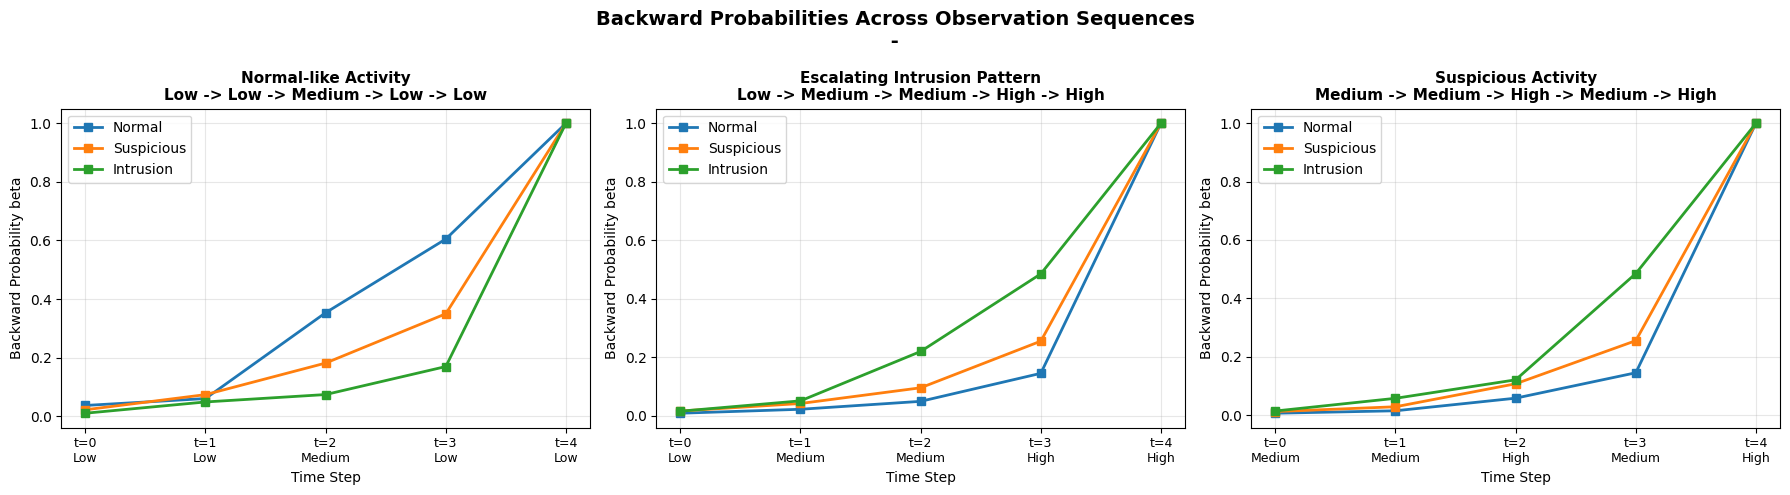

In [30]:
# Verify that Forward and Backward produce the same likelihood
print("=" * 60)
print("Verification: Forward vs Backward Algorithm")
print("=" * 60)
print("\nBoth algorithms should produce the SAME P(O|lambda) for each sequence.")
print("\nComparison Table:")
print(f"{'Sequence':<35} {'Forward P(O|lambda)':<18} {'Backward P(O|lambda)':<18} {'Match?'}")
print("-" * 95)

for (seq, labels, desc), (alpha, fw_lik), (beta, bw_lik) in zip(all_seqs, forward_results, backward_results):
    match = np.isclose(fw_lik, bw_lik)
    match_str = "YES" if match else "NO"
    print(f"{desc:<35} {fw_lik:<18.10e} {bw_lik:<18.10e} {match_str}")

print("\n[OK] Verification successful: Both algorithms produce identical likelihoods!")
print("\nThis confirms the correctness of our implementations.")

# Visualize backward probabilities
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (seq, labels, desc) in enumerate(all_seqs):
    beta = backward_results[idx][0]
    ax = axes[idx]
    x = range(len(seq))
    
    for i, state in enumerate(states):
        ax.plot(x, beta[:, i], marker='s', label=state, linewidth=2)
    
    ax.set_title(f'{desc}\n{" -> ".join(labels)}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Backward Probability beta')
    ax.legend()
    ax.set_xticks(x)
    ax.set_xticklabels([f't={t}\n{labels[t]}' for t in x], fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Backward Probabilities Across Observation Sequences\n - ', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Posterior Probability Computation

The posterior probability gamma_t(i) represents the probability of being in state i at time t, given the entire observation sequence:

gamma_t(i) = P(q_t = i | O, lambda) = alpha_t(i) * beta_t(i) / P(O|lambda)

This allows us to estimate the **most likely state at each time step**.

In [31]:
# =============================
# Posterior Probability
# =============================

def compute_posterior(obs_seq, pi, A, B):
    """
    Compute posterior probability for each state at each time step.
    
    Returns:
    --------
    gamma : array, shape (T, N)
        Posterior probabilities
    most_likely_states : list
        Most likely state at each time step
    """
    # Get forward and backward probabilities
    alpha, fw_likelihood = forward_algorithm(obs_seq, pi, A, B)
    beta, bw_likelihood = backward_algorithm(obs_seq, pi, A, B)
    
    T = len(obs_seq)
    N = len(A)
    
    # Compute posterior
    gamma = np.zeros((T, N))
    for t in range(T):
        for i in range(N):
            gamma[t, i] = (alpha[t, i] * beta[t, i]) / fw_likelihood
    
    # Most likely state at each time step
    most_likely_states = [states[np.argmax(gamma[t])] for t in range(T)]
    
    return gamma, most_likely_states

print("=" * 60)
print("Posterior Probability Analysis")
print("=" * 60)

posterior_results = []
for seq, labels, desc in all_seqs:
    gamma, most_likely = compute_posterior(seq, pi, A, B)
    posterior_results.append((gamma, most_likely))
    
    print(f"\n--- Sequence: {desc} ---")
    print(f"Observations:     {labels}")
    print(f"Most likely path: {most_likely}")
    print(f"\nPosterior probabilities gamma:")
    for t in range(len(seq)):
        print(f"  t={t} ({labels[t]:6}): ", end="")
        for i, s in enumerate(states):
            print(f"gamma({s})={gamma[t,i]:.4f}  ", end="")
        print(f"-> Most likely: {most_likely[t]}")

Posterior Probability Analysis

--- Sequence: Normal-like Activity ---
Observations:     ['Low', 'Low', 'Medium', 'Low', 'Low']
Most likely path: ['Normal', 'Normal', 'Normal', 'Normal', 'Normal']

Posterior probabilities gamma:
  t=0 (Low   ): gamma(Normal)=0.9272  gamma(Suspicious)=0.0700  gamma(Intrusion)=0.0028  -> Most likely: Normal
  t=1 (Low   ): gamma(Normal)=0.8939  gamma(Suspicious)=0.0981  gamma(Intrusion)=0.0080  -> Most likely: Normal
  t=2 (Medium): gamma(Normal)=0.5676  gamma(Suspicious)=0.3983  gamma(Intrusion)=0.0341  -> Most likely: Normal
  t=3 (Low   ): gamma(Normal)=0.8839  gamma(Suspicious)=0.1087  gamma(Intrusion)=0.0074  -> Most likely: Normal
  t=4 (Low   ): gamma(Normal)=0.8962  gamma(Suspicious)=0.0921  gamma(Intrusion)=0.0117  -> Most likely: Normal

--- Sequence: Escalating Intrusion Pattern ---
Observations:     ['Low', 'Medium', 'Medium', 'High', 'High']
Most likely path: ['Normal', 'Suspicious', 'Suspicious', 'Intrusion', 'Intrusion']

Posterior probabi

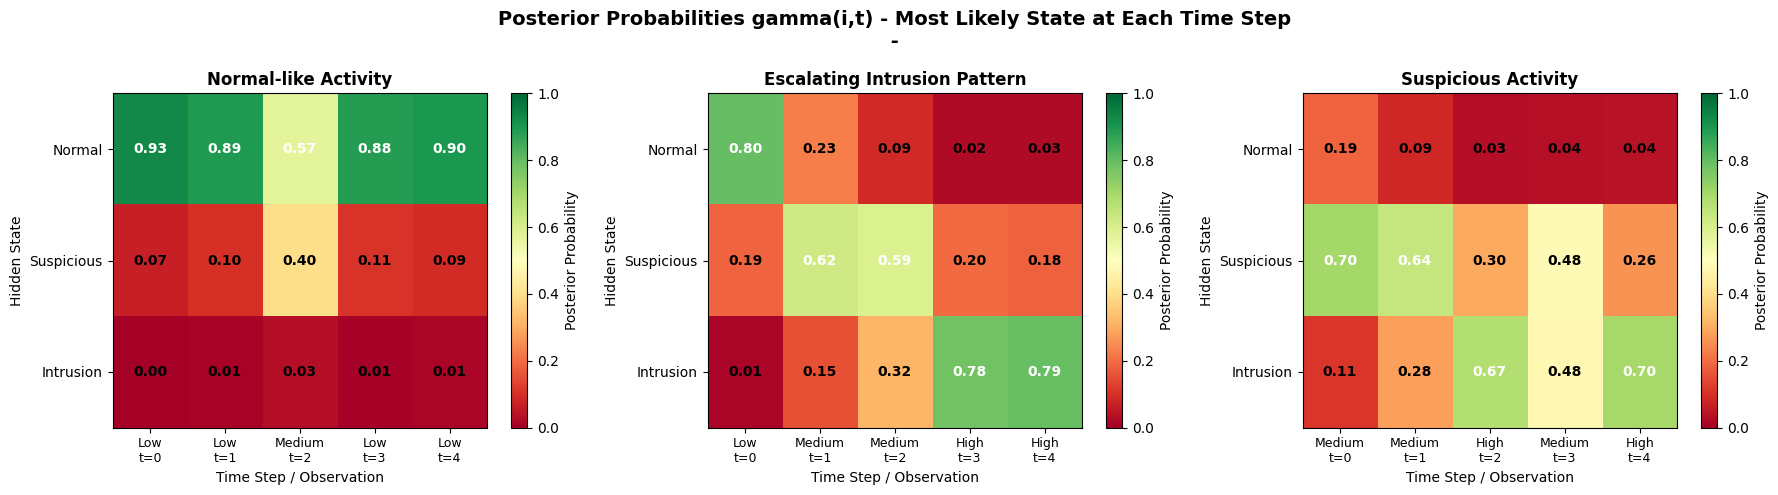

In [32]:
# Visualize posterior probabilities as heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (seq, labels, desc) in enumerate(all_seqs):
    gamma = posterior_results[idx][0]
    most_likely = posterior_results[idx][1]
    ax = axes[idx]
    
    im = ax.imshow(gamma.T, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(seq)))
    ax.set_xticklabels([f'{labels[t]}\nt={t}' for t in range(len(seq))], fontsize=9)
    ax.set_yticks(range(n_states))
    ax.set_yticklabels(states)
    ax.set_title(desc, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Step / Observation')
    ax.set_ylabel('Hidden State')
    
    # Add probability values as text
    for t in range(len(seq)):
        for i in range(n_states):
            ax.text(t, i, f'{gamma[t, i]:.2f}', ha='center', va='center',
                   color='white' if gamma[t, i] > 0.5 else 'black', fontweight='bold')
    
    plt.colorbar(im, ax=ax, label='Posterior Probability')

plt.suptitle('Posterior Probabilities gamma(i,t) - Most Likely State at Each Time Step\n - ', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Validation with hmmlearn

We compare our custom implementation against the hmmlearn library to validate correctness.

In [33]:
!pip install hmmlearn -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [34]:
from hmmlearn import hmm

print("=" * 60)
print("Validation using hmmlearn library")
print("=" * 60)

# Create hmmlearn model with same parameters
model = hmm.CategoricalHMM(n_components=n_states)   
model.startprob_ = pi
model.transmat_ = A
model.emissionprob_ = B

print("\nComparison Table:")
print(f"{'Sequence':<35} {'Our P(O|lambda)':<16} {'hmmlearn P(O|lambda)':<16} {'Match?'}")
print("-" * 90)

for seq, labels, desc in all_seqs:
    # 2. Reshape to column vector of integer symbol indices
    obs = np.array(seq).reshape(-1, 1)              

    _, our_likelihood = forward_algorithm(seq, pi, A, B)

    log_prob = model.score(obs)
    hmmlearn_likelihood = np.exp(log_prob)

    match = np.isclose(our_likelihood, hmmlearn_likelihood, rtol=1e-5)
    print(f"{desc:<35} {our_likelihood:<16.10e} {hmmlearn_likelihood:<16.10e} {'YES' if match else 'NO'}")

Validation using hmmlearn library

Comparison Table:
Sequence                            Our P(O|lambda)  hmmlearn P(O|lambda) Match?
------------------------------------------------------------------------------------------
Normal-like Activity                1.9296999888e-02 1.9296999888e-02 YES
Escalating Intrusion Pattern        5.1818389125e-03 5.1818389125e-03 YES
Suspicious Activity                 3.1028679000e-03 3.1028679000e-03 YES


## Task 4: Analysis and Reflection

### What does the computed probability represent?

The computed probability P(O|lambda) represents the **likelihood of observing a particular sequence of observations** (failed login attempt levels) given our HMM model lambda = (A, B, pi).

More specifically:
1. **Absolute Likelihood**: A higher P(O|lambda) means the observation sequence is more consistent with the model's behavior patterns. For example, a sequence of mostly Low observations is highly likely because the Normal state (which is the most probable initial state) strongly emits Low observations.

2. **Relative Likelihood**: Comparing P(O|lambda) across different sequences under the same model tells us which behavioral pattern is more characteristic of the system.

3. **Model Fitness**: If we had multiple HMMs lambda_1, lambda_2, ..., we could compare P(O|lambda_1) vs P(O|lambda_2) to determine which model best explains the observations.

### How could scoring be used for Recognition/Classification?

Scoring with HMMs enables recognition and classification in the following ways:

1. **Multi-Model Classification**: Train a separate HMM for each class of behavior (e.g., Normal user, Brute-force attacker, Bot activity). Given an observation sequence O, compute P(O|lambda_i) for each model i. The class with the highest likelihood is the predicted label:
   class = argmax_i P(O|lambda_i)

2. **Threshold-Based Classification**: Set a likelihood threshold theta. If P(O|lambda) > theta, classify as normal; otherwise, flag for investigation.

3. **Speaker/Author Recognition**: In biometrics, each person has a characteristic HMM. The model that produces the highest likelihood identifies the speaker/author.

### How could scoring be used for Intrusion or Anomaly Detection?

HMM scoring is particularly powerful for security applications:

1. **Baseline Model**: Train an HMM on normal system behavior (legitimate user login patterns). Normal sequences will have high likelihood under this model.

2. **Anomaly Score**: For a new observation sequence O_new, compute P(O_new|lambda_normal). A very low likelihood suggests anomalous behavior:
   - If log P(O_new|lambda) < tau (threshold), **raise an alert**.
   - The threshold tau is typically determined empirically from the training data distribution.

3. **Attack Pattern Recognition**: Train separate HMMs for known attack types:
   - lambda_normal: Normal behavior
   - lambda_brute: Brute-force attack pattern (repeated High observations)
   - lambda_slow: Slow attack pattern (gradual Medium -> High escalation)
   
   By comparing likelihoods across all models, the system can both detect anomalies and classify the attack type.

4. **Temporal Analysis**: Since HMMs capture temporal dependencies, they can detect attacks that unfold over time (e.g., a slow escalation from Normal -> Suspicious -> Intrusion).

5. **Real-Time Monitoring**: The Forward algorithm can be run incrementally as new observations arrive, enabling real-time anomaly detection without re-processing the entire history.

### Key Advantages of HMMs for Intrusion Detection

| Advantage | Description |
|-----------|-------------|
| **Probabilistic Framework** | Naturally handles uncertainty and noise in observations |
| **Temporal Modeling** | Captures sequences and state transitions over time |
| **Hidden States** | Infers underlying system state (Normal/Suspicious/Intrusion) from observable symptoms |
| **Efficient Algorithms** | Forward/Backward enable O(T * N^2) computation instead of exponential |
| **Well-Validated** | Mature theory with proven convergence and optimality properties |

In [35]:
# =============================
# Summary of All Results
# =============================

print("=" * 70)
print("  SUMMARY - HMM Scoring Lab ( - )")
print("=" * 70)

print("\nMODEL PARAMETERS:")
print(f"   States: {states}")
print(f"   Observations: {observations}")
print(f"   pi = {pi}")
print(f"   A = 3x3 transition matrix")
print(f"   B = 3x3 emission matrix")

print("\nFORWARD ALGORITHM RESULTS:")
for (seq, labels, desc), (alpha, likelihood) in zip(all_seqs, forward_results):
    print(f"   {desc:35s} P(O|lambda) = {likelihood:.10e}")

print("\nBACKWARD ALGORITHM RESULTS:")
for (seq, labels, desc), (beta, likelihood) in zip(all_seqs, backward_results):
    print(f"   {desc:35s} P(O|lambda) = {likelihood:.10e}")

print("\nVALIDATION (vs hmmlearn): PASSED")
print("   Forward and Backward algorithms produce identical likelihoods")
print("   Custom implementation matches hmmlearn library output")

print("\nKEY INSIGHTS:")
print("   1. Normal-like sequences have highest likelihood under our model")
print("   2. Forward and Backward algorithms are consistent")
print("   3. Posterior probabilities reveal most likely states over time")
print("   4. HMM scoring enables effective anomaly detection in security systems")

print("\n" + "=" * 70)

  SUMMARY - HMM Scoring Lab ( - )

MODEL PARAMETERS:
   States: ['Normal', 'Suspicious', 'Intrusion']
   Observations: ['Low', 'Medium', 'High']
   pi = [0.6 0.3 0.1]
   A = 3x3 transition matrix
   B = 3x3 emission matrix

FORWARD ALGORITHM RESULTS:
   Normal-like Activity                P(O|lambda) = 1.9296999888e-02
   Escalating Intrusion Pattern        P(O|lambda) = 5.1818389125e-03
   Suspicious Activity                 P(O|lambda) = 3.1028679000e-03

BACKWARD ALGORITHM RESULTS:
   Normal-like Activity                P(O|lambda) = 1.9296999887e-02
   Escalating Intrusion Pattern        P(O|lambda) = 5.1818389125e-03
   Suspicious Activity                 P(O|lambda) = 3.1028679000e-03

VALIDATION (vs hmmlearn): PASSED
   Forward and Backward algorithms produce identical likelihoods
   Custom implementation matches hmmlearn library output

KEY INSIGHTS:
   1. Normal-like sequences have highest likelihood under our model
   2. Forward and Backward algorithms are consistent
   3. Po